# Dự đoán nguy cơ mắc bệnh tim

Notebook này trình bày toàn bộ quy trình xử lý dữ liệu, xây dựng và so sánh các mô hình (MLP, Random Forest, XGBoost, SVM) nhằm dự đoán khả năng mắc bệnh tim dựa trên các chỉ số lâm sàng.


## Quy trình tổng quát
- Khảo sát dữ liệu, kiểm tra thiếu và ngoại lệ
- Làm sạch, chuẩn hóa và chọn đặc trưng
- Chia dữ liệu train/test (stratify theo nhãn)
- Huấn luyện MLP (Keras Sequential) và các mô hình so sánh: Random Forest, XGBoost, SVM
- Đánh giá Accuracy, Precision, Recall, F1, Specificity, AUC-ROC


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import xgboost as xgb
import tensorflow as tf
from tensorflow import keras

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [11]:
DATA_PATH = Path("heart.csv")
raw_df = pd.read_csv(DATA_PATH)
raw_df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [12]:
display(raw_df.shape)
display(raw_df.describe(include="all"))
display(raw_df.isna().sum())


(1025, 14)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

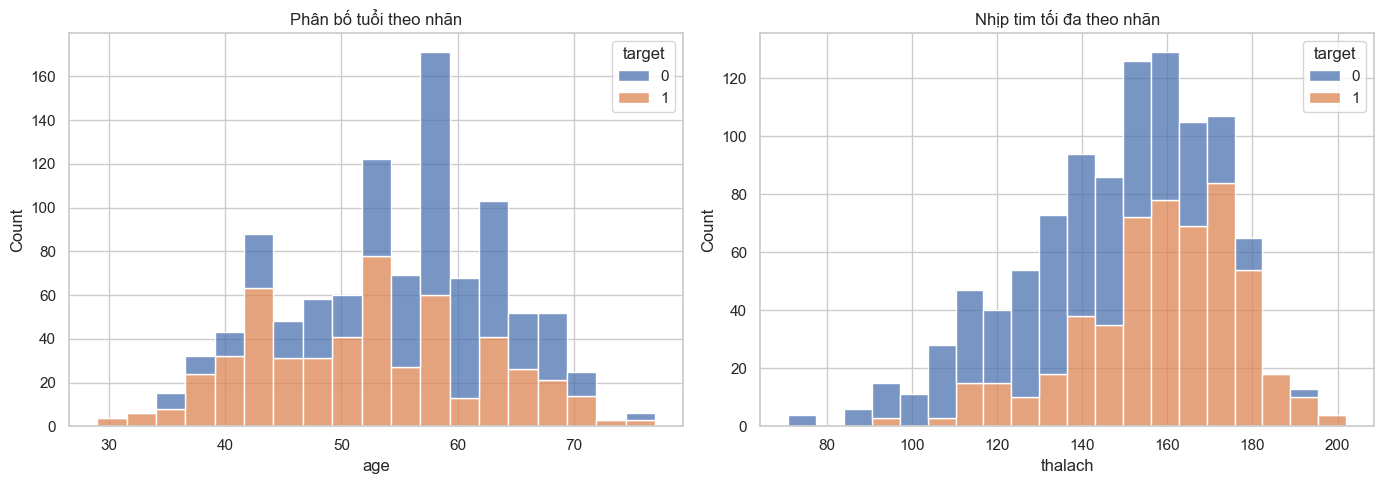

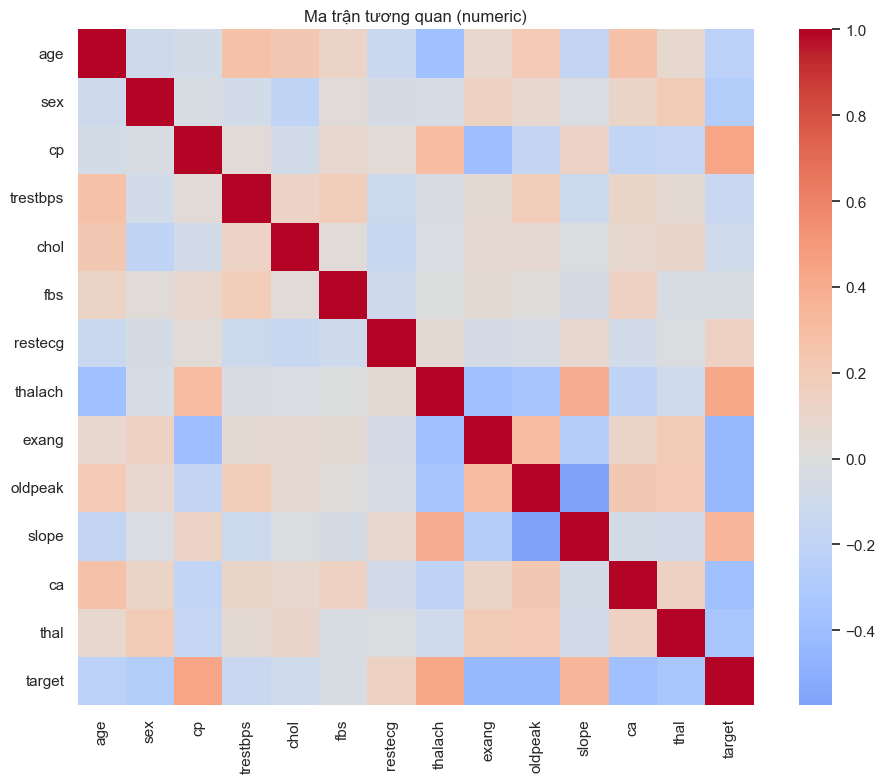

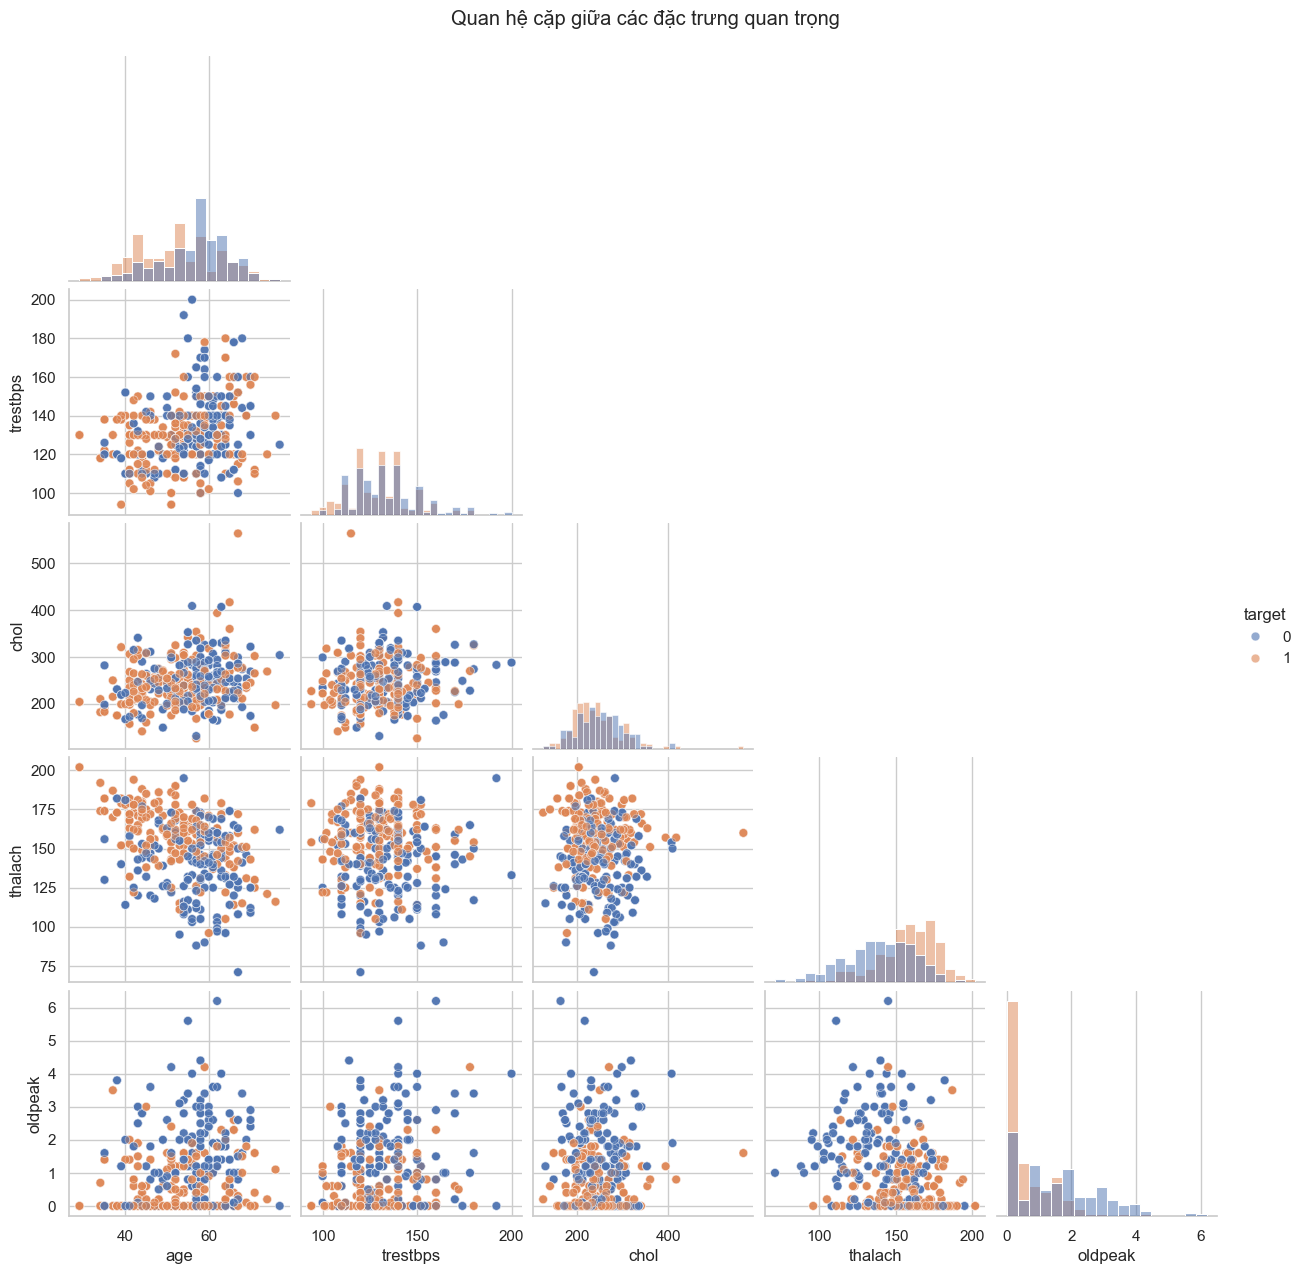

In [20]:
# Khảo sát nhanh phân phối và tương quan các đặc trưng chính
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=raw_df, x="age", hue="target", multiple="stack", ax=axes[0])
axes[0].set_title("Phân bố tuổi theo nhãn")
sns.histplot(data=raw_df, x="thalach", hue="target", multiple="stack", ax=axes[1])
axes[1].set_title("Nhịp tim tối đa theo nhãn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
corr = raw_df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Ma trận tương quan (numeric)")
plt.tight_layout()
plt.show()

pairplot_features = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
sns.pairplot(
    raw_df[pairplot_features],
    hue="target",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 40}
)
plt.suptitle("Quan hệ cặp giữa các đặc trưng quan trọng", y=1.02)
plt.show()

In [13]:
X = raw_df.drop(columns="target")
y = raw_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (717, 13), Test: (308, 13)


In [15]:

scaler = StandardScaler()
selector = SelectKBest(score_func=mutual_info_classif, k=min(10, X_train.shape[1]))

# Chuẩn hóa
X_train_proc = scaler.fit_transform(X_train, y_train)
X_test_proc = scaler.transform(X_test)

# Chọn đặc trưng
selector.fit(X_train_proc, y_train)

# Lấy mask đặc trưng được chọn
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask]
print("Đặc trưng được giữ lại:", list(selected_features))


Đặc trưng được giữ lại: ['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [16]:
def evaluate_model(name: str, y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    """Trả về bộ metric cho từng mô hình."""
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "specificity": specificity,
        "auc": auc
    }

results = []
roc_curves = {}



In [17]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

mlp_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_proc.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = mlp_model.fit(
    X_train_proc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

mlp_probs = mlp_model.predict(X_test_proc).ravel()
results.append(evaluate_model("MLP (Keras)", y_test.values, mlp_probs))
fpr, tpr, _ = roc_curve(y_test, mlp_probs)
roc_curves["MLP (Keras)"] = (fpr, tpr)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [18]:
results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
display(results_df)


,model,accuracy,precision,recall,f1,specificity,auc
0,MLP (Keras),0.974026,0.980769,0.968354,0.974522,0.98,0.991646


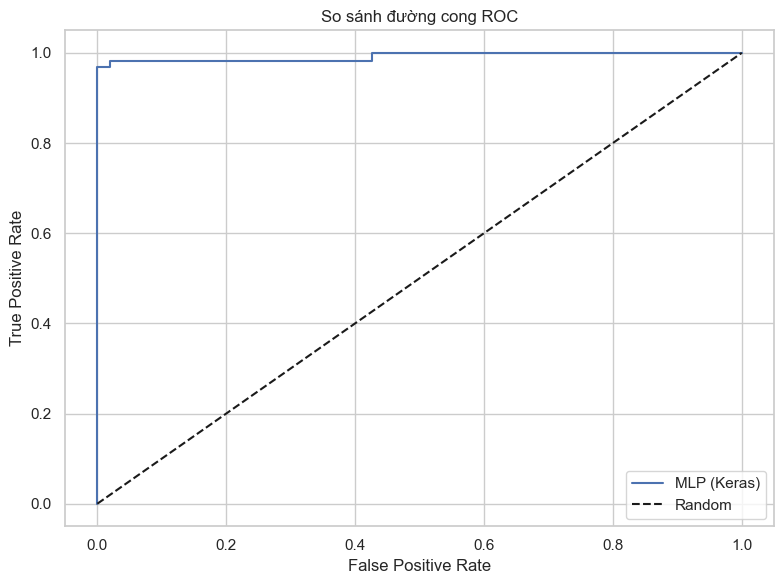

In [19]:
plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("So sánh đường cong ROC")
plt.legend()
plt.tight_layout()
plt.show()
